In [101]:
import pandas as pd
import numpy as np
from main import discount_monitor_df2df, DiscountedSumMonitor

In [102]:
params = {
    "data_source": "google-trace-data/cella_pdu6.csv",
    "data_column_name": "measured_power_util",
    "use_averages": True,
    "infR": 0.0,
    "supR": 1.0,
    "r": 0.9,
    "s": 0.9,
    "eps": 0.0002526735155491733,
    "T": 835.0,
    "L": 0.7108211591097413,
    "U": 0.7198746294207248,
    "save_csv": False
  }

r = params["r"]
s = params["s"]
infR = params["infR"]
supR = params["supR"]
R_bounds = (infR, supR)
I = (params["L"], params["U"])
eps = params["eps"]
T = params["T"]
avg = params["use_averages"]



In [103]:
orig_df = pd.read_csv("google-trace-data/cella_pdu6.csv").sort_values("time").reset_index()[["measured_power_util"]].rename(columns={"measured_power_util": "input"})

In [104]:
# randomly choose indices, # substitute with 1
noisy_df = orig_df.copy()
idx = np.random.choice(noisy_df.index[4000:5000], size=int(len(noisy_df) * 0.1), replace=False)
noisy_df.loc[idx, "input"] = 1.0
idx = np.random.choice(noisy_df.index[4000:5000], size=int(len(noisy_df) * 0.02), replace=False)
noisy_df.loc[idx, "input"] = 0.0

In [105]:
mon = DiscountedSumMonitor(r=r, s=s, R_bounds=R_bounds, I=I, eps=eps, T=T, use_averages = avg)
discounted_noisy_df = discount_monitor_df2df(noisy_df, mon)
discounted_noisy_df = discounted_noisy_df.rename(columns={"verdict":"discount_verdict_noisy", "input":"input_noisy"})

tau=121


In [106]:
mon = DiscountedSumMonitor(r=r, s=s, R_bounds=R_bounds, I=I, eps=eps, T=T, use_averages = avg)
discounted_df = discount_monitor_df2df(orig_df,mon)
discounted_df = discounted_df.rename(columns={"verdict":"discount_verdict"})

tau=121


In [107]:
df = discounted_df[["input", "discount_verdict"]].copy()
df["input_noisy"] = discounted_noisy_df["input_noisy"]
df["discount_verdict_noisy"] = discounted_noisy_df["discount_verdict_noisy"]

In [108]:
df

,input,discount_verdict,input_noisy,discount_verdict_noisy
0,0.659,NaN,0.659,NaN
1,0.657,NaN,0.657,NaN
2,0.664,NaN,0.664,NaN
3,0.673,NaN,0.673,NaN
4,0.677,NaN,0.677,NaN
...,...,...,...,...
8923,0.724,NaN,0.724,NaN
8924,0.723,NaN,0.723,NaN
8925,0.717,NaN,0.717,NaN
8926,0.718,NaN,0.718,NaN


In [109]:
tau = int((1+r)/(1-r))
tau = 1+2*int(2*np.ceil(tau/2)-1)
L, U = params["L"], params["U"]  

# --- validate tau ---
if tau % 2 == 0 or tau < 1:
    raise ValueError("tau must be a positive odd integer")

# --- centered window average; NaN at edges where window is incomplete ---
df["window_avg"] = (
    df["input"]
      .rolling(window=tau, center=True, min_periods=tau)
      .mean()
)

df["window_avg_noisy"] = (
    df["input_noisy"]
      .rolling(window=tau, center=True, min_periods=tau)
      .mean()
)

# --- whether the average lies within [L, U]; keep NaN where window_avg is NaN ---
df["window_verdict"] = np.where(
    df["window_avg"].isna(),
    np.nan,
    df["window_avg"].between(L, U, inclusive="both")
).astype("object")  # keeps mix of bool + NaN cleanly

df["window_verdict_noisy"] = np.where(
    df["window_avg_noisy"].isna(),
    np.nan,
    df["window_avg_noisy"].between(L, U, inclusive="both")
).astype("object")  # keeps mix of bool + NaN cleanly

In [110]:
df = df.dropna()
df["discount_false_positive"] = (df["discount_verdict"] == 0) & (df["discount_verdict_noisy"] ==1)
df["discount_false_negative"] = (df["discount_verdict"] == 1) & (df["discount_verdict_noisy"] ==0)

df["window_false_positive"] = (df["window_verdict"] == 0) & (df["window_verdict_noisy"] ==1)
df["window_false_negative"] = (df["window_verdict"] == 1) & (df["window_verdict_noisy"] ==0)
# df["window_error"] = df["window_verdict"] == df["window_verdict_noisy"]

/var/folders/ql/07sh8qjn4g91mb3_rzdd2mk40000gn/T/ipykernel_70010/3692065220.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["discount_false_positive"] = (df["discount_verdict"] == 0) & (df["discount_verdict_noisy"] ==1)
/var/folders/ql/07sh8qjn4g91mb3_rzdd2mk40000gn/T/ipykernel_70010/3692065220.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["discount_false_negative"] = (df["discount_verdict"] == 1) & (df["discount_verdict_noisy"] ==0)
/var/folders/ql/07sh8qjn4g91mb3_rzdd2mk40000gn/T/ipykernel

In [111]:
df

,input,discount_verdict,input_noisy,discount_verdict_noisy,window_avg,window_avg_noisy,window_verdict,window_verdict_noisy,discount_false_positive,discount_false_negative,window_false_positive,window_false_negative
835,0.646,0.0,0.646,0.0,0.684513,0.684513,0.0,0.0,False,False,False,False
836,0.642,0.0,0.642,0.0,0.684615,0.684615,0.0,0.0,False,False,False,False
837,0.641,0.0,0.641,0.0,0.684795,0.684795,0.0,0.0,False,False,False,False
838,0.644,0.0,0.644,0.0,0.684821,0.684821,0.0,0.0,False,False,False,False
839,0.641,0.0,0.641,0.0,0.684744,0.684744,0.0,0.0,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8890,0.725,0.0,0.725,0.0,0.730846,0.730846,0.0,0.0,False,False,False,False
8891,0.726,0.0,0.726,0.0,0.731179,0.731179,0.0,0.0,False,False,False,False
8892,0.728,0.0,0.728,0.0,0.731308,0.731308,0.0,0.0,False,False,False,False
8893,0.732,0.0,0.732,0.0,0.731385,0.731385,0.0,0.0,False,False,False,False


In [112]:
print(f"{df['discount_false_negative'].sum()=}")
print(f"{df['discount_false_positive'].sum()=}")

print(f"{df['window_false_negative'].sum()=}")
print(f"{df['window_false_positive'].sum()=}")

df['discount_false_negative'].sum()=170
df['discount_false_positive'].sum()=33
df['window_false_negative'].sum()=149
df['window_false_positive'].sum()=26


In [113]:
x = df["input"].to_numpy(dtype=float)
n = x.size
Lsum = np.zeros(n, dtype=float)
for t in range(1, n):
    # Lsum[t] = r * (x[t-1] + Lsum[t-1])
    Lsum[t] = r * (x[t - 1] + Lsum[t - 1])

# --- discounted sums on the right: Rsum[t] = sum_{i=1..n-1-t} r^i * x[t+i]
Rsum = np.zeros(n, dtype=float)
for t in range(n - 2, -1, -1):
    # Rsum[t] = r * (x[t+1] + Rsum[t+1])
    Rsum[t] = r * (x[t + 1] + Rsum[t + 1])

# --- weight normalizer (available weights only)
# Wleft[t]  = sum_{i=1..t} r^i     = r * (1 - r^t) / (1 - r)   (for r!=1)
# Wright[t] = sum_{i=1..n-1-t} r^i = r * (1 - r^(n-1-t)) / (1 - r)
idx = np.arange(n)
Wleft  = np.where(r == 0, 0.0, r * (1.0 - r**idx) / (1.0 - r))
Wright = np.where(r == 0, 0.0, r * (1.0 - r**(n - 1 - idx)) / (1.0 - r))
W = 1.0 + Wleft + Wright

df["disc_avg"] = (x + Lsum + Rsum) / W

# If you want NaN whenever input is NaN (recommended):
df.loc[df["input"].isna(), "disc_avg"] = np.nan

# --- in-target flag, keeping NaN when disc_avg is NaN
df["disc_in_target"] = np.where(
    df["disc_avg"].isna(),
    np.nan,
    pd.Series(df["disc_avg"]).between(L, U, inclusive="both")
).astype("object")

/var/folders/ql/07sh8qjn4g91mb3_rzdd2mk40000gn/T/ipykernel_70010/3046621167.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["disc_avg"] = (x + Lsum + Rsum) / W
/var/folders/ql/07sh8qjn4g91mb3_rzdd2mk40000gn/T/ipykernel_70010/3046621167.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["disc_in_target"] = np.where(


In [114]:
x = df["input_noisy"].to_numpy(dtype=float)
n = x.size
Lsum = np.zeros(n, dtype=float)
for t in range(1, n):
    # Lsum[t] = r * (x[t-1] + Lsum[t-1])
    Lsum[t] = r * (x[t - 1] + Lsum[t - 1])

# --- discounted sums on the right: Rsum[t] = sum_{i=1..n-1-t} r^i * x[t+i]
Rsum = np.zeros(n, dtype=float)
for t in range(n - 2, -1, -1):
    # Rsum[t] = r * (x[t+1] + Rsum[t+1])
    Rsum[t] = r * (x[t + 1] + Rsum[t + 1])

# --- weight normalizer (available weights only)
# Wleft[t]  = sum_{i=1..t} r^i     = r * (1 - r^t) / (1 - r)   (for r!=1)
# Wright[t] = sum_{i=1..n-1-t} r^i = r * (1 - r^(n-1-t)) / (1 - r)
idx = np.arange(n)
Wleft  = np.where(r == 0, 0.0, r * (1.0 - r**idx) / (1.0 - r))
Wright = np.where(r == 0, 0.0, r * (1.0 - r**(n - 1 - idx)) / (1.0 - r))
W = 1.0 + Wleft + Wright

df["disc_avg_noisy"] = (x + Lsum + Rsum) / W

# If you want NaN whenever input is NaN (recommended):
df.loc[df["input_noisy"].isna(), "disc_avg_noisy"] = np.nan

# --- in-target flag, keeping NaN when disc_avg is NaN
df["disc_in_target_noisy"] = np.where(
    df["disc_avg_noisy"].isna(),
    np.nan,
    pd.Series(df["disc_avg_noisy"]).between(L, U, inclusive="both")
).astype("object")

/var/folders/ql/07sh8qjn4g91mb3_rzdd2mk40000gn/T/ipykernel_70010/3335601365.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["disc_avg_noisy"] = (x + Lsum + Rsum) / W
/var/folders/ql/07sh8qjn4g91mb3_rzdd2mk40000gn/T/ipykernel_70010/3335601365.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["disc_in_target_noisy"] = np.where(


In [115]:
df["discount_exact_false_positive"] = (df["disc_in_target"] == 0) & (df["disc_in_target_noisy"] ==1)
df["discount_exact_false_negative"] = (df["disc_in_target"] == 1) & (df["disc_in_target_noisy"] ==0)

/var/folders/ql/07sh8qjn4g91mb3_rzdd2mk40000gn/T/ipykernel_70010/1895788747.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["discount_exact_false_positive"] = (df["disc_in_target"] == 0) & (df["disc_in_target_noisy"] ==1)
/var/folders/ql/07sh8qjn4g91mb3_rzdd2mk40000gn/T/ipykernel_70010/1895788747.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["discount_exact_false_negative"] = (df["disc_in_target"] == 1) & (df["disc_in_target_noisy"] ==0)


In [116]:
print(f"{df['discount_false_negative'][4000:5000].sum()=}")
print(f"{df['discount_false_positive'][4000:5000].sum()=}")

print(f"{df['discount_exact_false_negative'][4000:5000].sum()=}")
print(f"{df['discount_exact_false_positive'][4000:5000].sum()=}")

print(f"{df['window_false_negative'][4000:5000].sum()=}")
print(f"{df['window_false_positive'][4000:5000].sum()=}")

df['discount_false_negative'][4000:5000].sum()=47
df['discount_false_positive'][4000:5000].sum()=12
df['discount_exact_false_negative'][4000:5000].sum()=48
df['discount_exact_false_positive'][4000:5000].sum()=10
df['window_false_negative'][4000:5000].sum()=56
df['window_false_positive'][4000:5000].sum()=11


In [117]:
df

,input,discount_verdict,input_noisy,discount_verdict_noisy,window_avg,window_avg_noisy,window_verdict,window_verdict_noisy,discount_false_positive,discount_false_negative,window_false_positive,window_false_negative,disc_avg,disc_in_target,disc_avg_noisy,disc_in_target_noisy,discount_exact_false_positive,discount_exact_false_negative
835,0.646,0.0,0.646,0.0,0.684513,0.684513,0.0,0.0,False,False,False,False,0.663958,0.0,0.663958,0.0,False,False
836,0.642,0.0,0.642,0.0,0.684615,0.684615,0.0,0.0,False,False,False,False,0.664306,0.0,0.664306,0.0,False,False
837,0.641,0.0,0.641,0.0,0.684795,0.684795,0.0,0.0,False,False,False,False,0.665005,0.0,0.665005,0.0,False,False
838,0.644,0.0,0.644,0.0,0.684821,0.684821,0.0,0.0,False,False,False,False,0.666025,0.0,0.666025,0.0,False,False
839,0.641,0.0,0.641,0.0,0.684744,0.684744,0.0,0.0,False,False,False,False,0.667292,0.0,0.667292,0.0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8890,0.725,0.0,0.725,0.0,0.730846,0.730846,0.0,0.0,False,False,False,False,0.726104,0.0,0.726104,0.0,False,False
8891,0.726,0.0,0.726,0.0,0.731179,0.731179,0.0,0.0,False,False,False,False,0.726301,0.0,0.726301,0.0,False,False
8892,0.728,0.0,0.728,0.0,0.731308,0.731308,0.0,0.0,False,False,False,False,0.726526,0.0,0.726526,0.0,False,False
8893,0.732,0.0,0.732,0.0,0.731385,0.731385,0.0,0.0,False,False,False,False,0.726754,0.0,0.726754,0.0,False,False


In [118]:
np.sum((df.window_avg - df.window_avg_noisy)**2)

8.607851009861935

In [119]:
np.sum((df.disc_avg - df.disc_avg_noisy)**2)

8.82179446298926

In [37]:
df.in_target.sum()

809.0

In [18]:
r=0.9

tau = (1+r)/(1-r)

In [19]:
tau

19.000000000000004

In [125]:
v = np.logspace(np.log10(0.1), np.log10(0.0001), 5)


In [126]:
v

array([0.1       , 0.01778279, 0.00316228, 0.00056234, 0.0001    ])

In [127]:
np.arange(10)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [131]:
times = np.arange(0,10000)
ps = np.sin((np.pi/1000)*times)

In [132]:
ps

array([ 0.        ,  0.00314159,  0.00628314, ..., -0.00942464,
       -0.00628314, -0.00314159])

In [135]:
np.random.rand()

0.9915237901070634

In [138]:

times = np.arange(0,10000)
ps = np.sin((np.pi/1000)*times)
xs = 0*ps
for i in range(len(times)):
    p = ps[i]
    xs[i] = 1 if np.random.rand() < p else 0
df_dict = {
    "t" : times,
    "p" : ps,
    "input" : xs
}
df = pd.DataFrame(df_dict)

In [141]:

from matplotlib import pyplot as plt

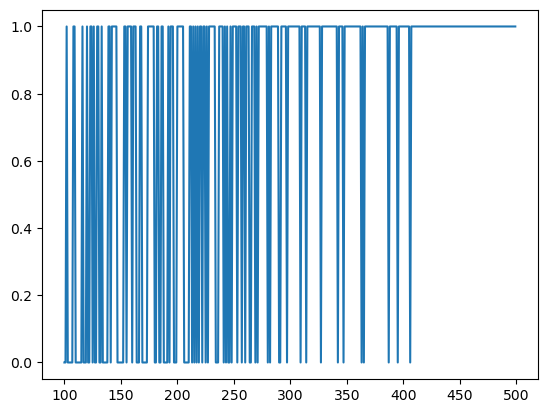

In [145]:
plt.plot(df.t[100:500], df.input[100:500])

In [146]:
np.logspace(np.log10(0.25), np.log10(0.0025), 8)

array([0.25      , 0.12948687, 0.06706739, 0.03473739, 0.01799214,
       0.00931898, 0.00482674, 0.0025    ])

In [215]:
orig_trace_df = pd.read_csv("stochastic_traces/sin1000_4.csv")
df = pd.read_csv("experimental-results/stochastic_interval_length_0.12948686698078027_4.csv")
df["p"] = orig_trace_df["p"]
L = 0.5-0.1294
U = 0.5+0.1294

In [216]:
p = df["p"]
n = len(p)

# past contributions
past = sum(
    (s**i) * p.shift(i)
    for i in range(1, n)
)

# future contributions
future = sum(
    (r**i) * p.shift(-i)
    for i in range(1, n)
)

df["discounted_p"] = p + past.fillna(0) + future.fillna(0)

df["ground_truth_verdict"] = ((df["discounted_p"] >= L) & (df["discounted_p"] <= U)).astype(int)

df_nonan = df.dropna()
accuracy=(df_nonan.verdict == df_nonan.ground_truth_verdict).sum()/len(df_nonan)


In [217]:
df

,Unnamed: 0,input,verdict,time_verdict,valL,valU,active_monitors,wait_time,active_monitors_normalized,p,discounted_p,ground_truth_verdict
0,0,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.000000,0.000000,0.016817,0
1,1,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.000000,0.000010,0.000010,0
2,2,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.000000,0.000039,0.000039,0
3,3,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.000000,0.000089,0.000089,0
4,4,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.000000,0.000158,0.000158,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9995,0.0,NaN,NaN,NaN,NaN,32.0,NaN,0.278261,0.000247,0.000247,0
9996,9996,0.0,NaN,NaN,NaN,NaN,32.0,NaN,0.278261,0.000158,0.000158,0
9997,9997,0.0,NaN,NaN,NaN,NaN,32.0,NaN,0.278261,0.000089,0.000089,0
9998,9998,0.0,NaN,NaN,NaN,NaN,32.0,NaN,0.278261,0.000039,0.000039,0


In [218]:
accuracy

0.9267395182872435

In [213]:
(df_nonan.verdict == df_nonan.ground_truth_verdict)

1000    True
1001    True
1002    True
1003    True
1004    True
        ... 
9963    True
9964    True
9965    True
9966    True
9967    True
Length: 8968, dtype: bool

In [214]:
len(df_nonan)

8968

<Axes: >

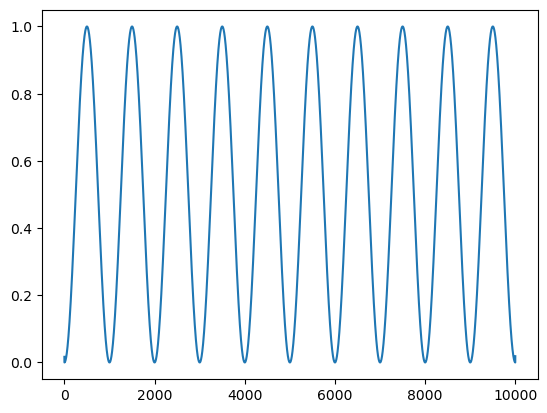

In [219]:
df.discounted_p.plot()

In [221]:
1 + 2*r/(1-r)

19.000000000000004

In [205]:
accuracy

0.9047725245316681

In [191]:
((df_nonan.verdict == 0) & (df_nonan.ground_truth_verdict == 0)).sum()

6928

In [ ]:
df["real_verdict"] = df["dis"]

In [159]:
df

,Unnamed: 0,input,verdict,time_verdict,valL,valU,active_monitors,wait_time,active_monitors_normalized,p
0,0,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.000000,0.000000
1,1,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.000000,0.003142
2,2,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.000000,0.006283
3,3,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.000000,0.009425
4,4,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.000000,0.012566
...,...,...,...,...,...,...,...,...,...,...
9995,9995,0.0,NaN,NaN,NaN,NaN,32.0,NaN,0.278261,-0.015707
9996,9996,0.0,NaN,NaN,NaN,NaN,32.0,NaN,0.278261,-0.012566
9997,9997,0.0,NaN,NaN,NaN,NaN,32.0,NaN,0.278261,-0.009425
9998,9998,0.0,NaN,NaN,NaN,NaN,32.0,NaN,0.278261,-0.006283


<Axes: >

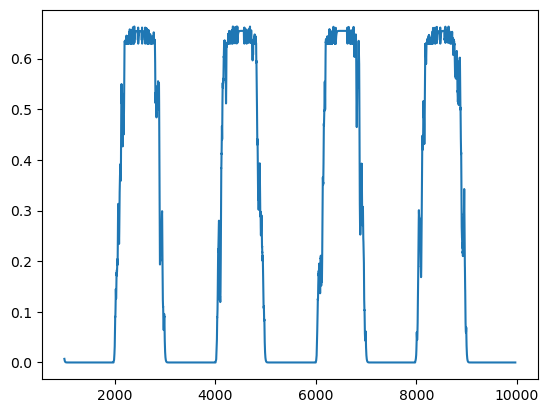

In [160]:
df.dropna().

<Axes: >

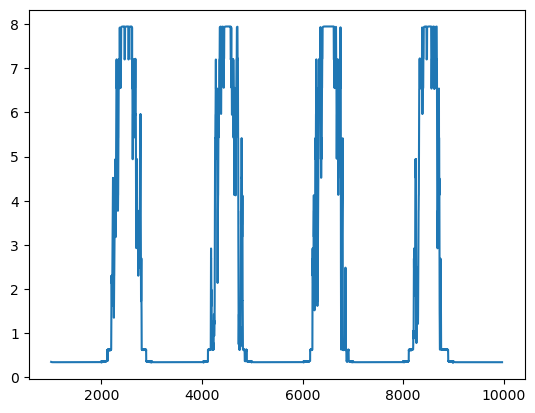

In [161]:
df.dropna().valU.plot()

<Axes: >

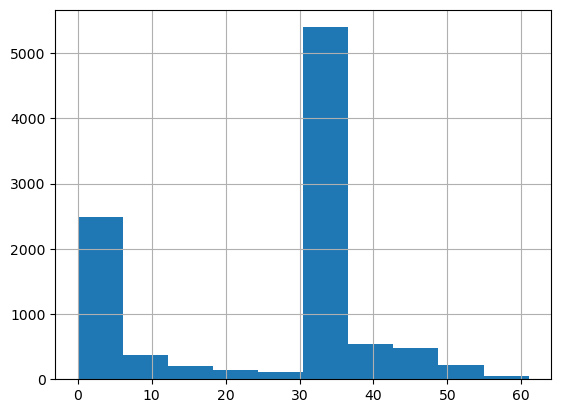

In [162]:
df.active_monitors.hist()

<Axes: >

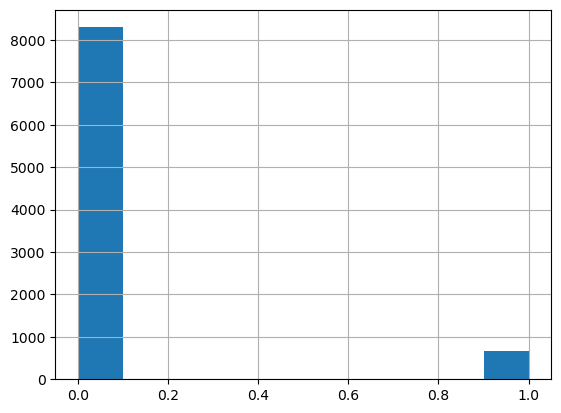

In [163]:
df.verdict.hist()

In [153]:
orig_trace_df

,Unnamed: 0,time,p,input
0,0,0,0.000000,0.0
1,1,1,0.003142,0.0
2,2,2,0.006283,0.0
3,3,3,0.009425,0.0
4,4,4,0.012566,0.0
...,...,...,...,...
9995,9995,9995,-0.015707,0.0
9996,9996,9996,-0.012566,0.0
9997,9997,9997,-0.009425,0.0
9998,9998,9998,-0.006283,0.0


In [149]:
df

,Unnamed: 0,input,verdict,time_verdict,valL,valU,active_monitors,wait_time,active_monitors_normalized
0,0,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.000000
1,1,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.000000
2,2,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.000000
3,3,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.000000
4,4,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.000000
...,...,...,...,...,...,...,...,...,...
9995,9995,0.0,NaN,NaN,NaN,NaN,32.0,NaN,0.367816
9996,9996,0.0,NaN,NaN,NaN,NaN,32.0,NaN,0.367816
9997,9997,0.0,NaN,NaN,NaN,NaN,32.0,NaN,0.367816
9998,9998,0.0,NaN,NaN,NaN,NaN,32.0,NaN,0.367816


In [164]:
def compute_newp(df, r, s):
    p = df["p"]
    n = len(p)

    # past contributions
    past = sum(
        (s**i) * p.shift(i)
        for i in range(1, n)
    )

    # future contributions
    future = sum(
        (r**i) * p.shift(-i)
        for i in range(1, n)
    )

    df["discounted_p"] = p + past.fillna(0) + future.fillna(0)
    return df

In [ ]:
df = 